
# soft-TT check of the $2/n$ residue pattern

This notebook implements the classical check suggested by Jim, with one important refinement.

A naive quadrupole-like TT quantity,
$$
Q_{\rm naive}
=
\left[\sum_i(p_{x,i}^2-p_{y,i}^2)\right]^2
+
4\left[\sum_i p_{x,i}p_{y,i}\right]^2,
$$
falls faster than $2/n$ because each particle is weighted by $E_i^2$.

For comparison with the Weinberg soft-graviton residue, the classical soft source should include the eikonal denominator
$$
\frac{p_i^\mu p_i^\nu}{p_i\cdot \omega}.
$$
For a soft graviton moving along the $z$ direction,
$$
p_i\cdot \omega = E_\omega(E_i-p_{z,i}).
$$
Up to the common factor $1/E_\omega$, the relevant transverse-traceless source is therefore
$$
T_+
=
\sum_i \frac{p_{x,i}^2-p_{y,i}^2}{E_i-p_{z,i}},
\qquad
T_\times
=
2\sum_i \frac{p_{x,i}p_{y,i}}{E_i-p_{z,i}},
$$
and
$$
Q_{\rm soft}^{\rm TT}
=
T_+^2+T_\times^2.
$$

We generate flat massless $n$-body phase space with RAMBO and test whether
$$
\frac{\langle Q_{\rm soft}^{\rm TT}\rangle_n}
{\langle Q_{\rm soft}^{\rm TT}\rangle_2}
\simeq \frac{2}{n}.
$$


In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath, amssymb}"
plt.rc('font', **{'family': 'serif', 'size': 15})

rng = np.random.default_rng(12345)



## RAMBO generator for massless $n$-body phase space

The output momenta satisfy
$$
\sum_i p_i^\mu=(M,0,0,0),\qquad p_i^2=0.
$$


In [2]:

def rambo_massless(n, n_events, M=1.0, rng=None):
    """
    Generate massless n-body phase space with total four-momentum (M,0,0,0).

    Parameters
    ----------
    n : int
        Final-state multiplicity.
    n_events : int
        Number of events.
    M : float
        Parent mass / total energy.
    rng : np.random.Generator

    Returns
    -------
    p : ndarray, shape (n_events, n, 4)
        Four-momenta with components (E, px, py, pz).
    """
    if rng is None:
        rng = np.random.default_rng()

    # Random directions
    c = rng.uniform(-1.0, 1.0, size=(n_events, n))
    phi = rng.uniform(0.0, 2.0*np.pi, size=(n_events, n))
    s = np.sqrt(1.0 - c**2)

    # RAMBO massless trial energies
    r1 = rng.random(size=(n_events, n))
    r2 = rng.random(size=(n_events, n))
    q0 = -np.log(r1 * r2)

    q = np.empty((n_events, n, 4), dtype=float)
    q[:, :, 0] = q0
    q[:, :, 1] = q0 * s * np.cos(phi)
    q[:, :, 2] = q0 * s * np.sin(phi)
    q[:, :, 3] = q0 * c

    # Total trial four-vector
    Q = q.sum(axis=1)
    Q0 = Q[:, 0]
    Qvec = Q[:, 1:]
    Qmass2 = Q0**2 - np.sum(Qvec**2, axis=1)
    Qmass = np.sqrt(np.maximum(Qmass2, 0.0))

    # Boost by beta = -Qvec/Q0 to the Q rest frame
    beta = -Qvec / Q0[:, None]
    beta2 = np.sum(beta**2, axis=1)
    gamma = 1.0 / np.sqrt(1.0 - beta2)

    q0_old = q[:, :, 0]
    qvec_old = q[:, :, 1:]
    beta_dot_q = np.einsum("ei,eni->en", beta, qvec_old)

    q0_new = gamma[:, None] * (q0_old + beta_dot_q)

    factor = np.zeros_like(beta2)
    mask = beta2 > 1e-30
    factor[mask] = (gamma[mask] - 1.0) / beta2[mask]

    qvec_new = (
        qvec_old
        + factor[:, None, None] * beta[:, None, :] * beta_dot_q[:, :, None]
        + gamma[:, None, None] * beta[:, None, :] * q0_old[:, :, None]
    )

    # Rescale to total energy M
    scale = M / Qmass
    p = np.empty_like(q)
    p[:, :, 0] = scale[:, None] * q0_new
    p[:, :, 1:] = scale[:, None, None] * qvec_new

    return p


def check_conservation(p, M=1.0):
    total = p.sum(axis=1)
    E_total = total[:, 0]
    P_total = total[:, 1:]
    mass2_each = p[:, :, 0]**2 - np.sum(p[:, :, 1:]**2, axis=2)

    return {
        "max |E_total - M|": np.max(np.abs(E_total - M)),
        "max |P_total|": np.max(np.linalg.norm(P_total, axis=1)),
        "max |p_i^2|": np.max(np.abs(mass2_each)),
    }



## Naive TT quantity


In [3]:

def q_naive_tt(p):
    """
    Naive quadrupole-like TT strength for a GW propagating along z.
    This does NOT include the Weinberg soft denominators.
    """
    px = p[:, :, 1]
    py = p[:, :, 2]

    T_plus = np.sum(px**2 - py**2, axis=1)
    T_cross = 2.0 * np.sum(px * py, axis=1)

    return T_plus**2 + T_cross**2



## Soft-eikonal TT quantity

This is the classical analog of the Weinberg soft factor.

For a soft graviton moving along $z$,
$$
p_i\cdot \omega = E_\omega(E_i-p_{z,i}).
$$
The common $E_\omega$ factor cancels in ratios, so we use $E_i-p_{z,i}$.


In [4]:

def q_soft_tt(p, eps=1e-15):
    """
    Soft-theorem TT strength for a soft graviton propagating along z.

    Computes

        [sum_i (px_i^2 - py_i^2)/(E_i - pz_i)]^2
      + 4 [sum_i px_i py_i/(E_i - pz_i)]^2

    up to the common overall factor 1/E_omega^2.

    For massless momenta this is finite in the collinear direction because
    px,py -> 0 at the same time as E-pz -> 0. The eps only protects against
    floating-point roundoff.
    """
    E  = p[:, :, 0]
    px = p[:, :, 1]
    py = p[:, :, 2]
    pz = p[:, :, 3]

    denom = E - pz
    denom = np.maximum(denom, eps)

    T_plus = np.sum((px**2 - py**2) / denom, axis=1)
    T_cross = 2.0 * np.sum(px * py / denom, axis=1)

    return T_plus**2 + T_cross**2



## Monte Carlo estimator


In [5]:

def estimate_average(n, observable, n_events=300_000, batch_size=30_000, M=1.0, seed=12345):
    """
    Estimate the phase-space average of an observable using batched RAMBO.
    """
    local_rng = np.random.default_rng(seed + n)
    vals = []

    remaining = n_events
    while remaining > 0:
        m = min(batch_size, remaining)
        p = rambo_massless(n, m, M=M, rng=local_rng)
        vals.append(observable(p))
        remaining -= m

    vals = np.concatenate(vals)
    mean = vals.mean()
    err = vals.std(ddof=1) / np.sqrt(vals.size)
    return mean, err


def run_scan(n_values, observable, label, n_events=300_000, batch_size=30_000, M=1.0, seed=12345):
    rows = []
    for n in n_values:
        mean, err = estimate_average(
            n,
            observable,
            n_events=n_events,
            batch_size=batch_size,
            M=M,
            seed=seed,
        )
        rows.append({"n": n, f"<{label}>": mean, "MC error": err})

    df = pd.DataFrame(rows)

    q2 = df.loc[df["n"] == 2, f"<{label}>"].iloc[0]
    q2_err = df.loc[df["n"] == 2, "MC error"].iloc[0]

    df["ratio to n=2"] = df[f"<{label}>"] / q2
    df["2/n"] = 2.0 / df["n"]
    df["ratio / (2/n)"] = df["ratio to n=2"] / df["2/n"]

    df["ratio error"] = df["ratio to n=2"] * np.sqrt(
        (df["MC error"] / df[f"<{label}>"])**2 + (q2_err / q2)**2
    )

    return df



## Check momentum conservation


In [6]:

p_test = rambo_massless(4, 10_000, M=1.0, rng=np.random.default_rng(999))
check_conservation(p_test)


{'max |E_total - M|': np.float64(3.3306690738754696e-15),
 'max |P_total|': np.float64(7.853417926740642e-15),
 'max |p_i^2|': np.float64(2.581268532253489e-15)}


## Run the corrected soft-eikonal TT test


In [7]:
def make_n_values(n_min=2, n_max=100, step=1):
    """
    Generate a list of final-state multiplicities.

    Example:
        make_n_values(2, 20) -> [2, 3, ..., 20]
        make_n_values(2, 30, 2) -> [2, 4, 6, ..., 30]
    """
    return list(range(n_min, n_max + 1, step))

n_values = make_n_values(n_min=2, n_max=100)

n_events = 300_000

df_soft = run_scan(
    n_values,
    q_soft_tt,
    label="Q_soft_TT",
    n_events=n_events,
    batch_size=30_000,
    M=1.0,
    seed=12345,
)

df_soft


,n,<Q_soft_TT>,MC error,ratio to n=2,2/n,ratio / (2/n),ratio error
0,2,1.000000,5.566421e-15,1.000000,1.000000,1.000000,7.872108e-15
1,3,0.665622,5.445696e-04,0.665622,0.666667,0.998433,5.445696e-04
2,4,0.499559,5.271653e-04,0.499559,0.500000,0.999118,5.271653e-04
3,5,0.400217,4.776857e-04,0.400217,0.400000,1.000541,4.776857e-04
4,6,0.332874,4.301042e-04,0.332874,0.333333,0.998623,4.301042e-04
...,...,...,...,...,...,...,...
94,96,0.020846,3.729327e-05,0.020846,0.020833,1.000619,3.729327e-05
95,97,0.020651,3.688337e-05,0.020651,0.020619,1.001595,3.688337e-05
96,98,0.020423,3.648204e-05,0.020423,0.020408,1.000746,3.648204e-05
97,99,0.020168,3.619466e-05,0.020168,0.020202,0.998302,3.619466e-05



## Diagnostic: compare with the naive TT quantity

The naive object falls faster because it weights each particle by $E_i^2$ rather than the soft-eikonal weight.


In [ ]:

# df_naive = run_scan(
#     n_values,
#     q_naive_tt,
#     label="Q_naive_TT",
#     n_events=n_events,
#     batch_size=30_000,
#     M=1.0,
#     seed=54321,
# )

# df_naive


In [8]:
# plt.figure(figsize=(5, 5))

# plt.errorbar(
#     df_soft["n"],
#     df_soft["ratio to n=2"],
#     yerr=df_soft["ratio error"],
#     marker="o",
#     linestyle="none",
#     label=r"$Q \sim p_i^a p_i^b/(p_i \cdot \omega)$",
# )

# plt.errorbar(
#     df_naive["n"],
#     df_naive["ratio to n=2"],
#     yerr=df_naive["ratio error"],
#     marker="s",
#     linestyle="none",
#     label=r"$Q \sim p_i^a p_i^b$",
# )

# plt.plot(
#     df_soft["n"],
#     df_soft["2/n"],
#     linestyle="--",
#     label=r"$2/n$",
# )

# plt.xlabel(r"final-state multiplicity $n$")
# plt.ylabel(
#     r"$\langle Q^{\rm TT}\rangle_n/\langle Q^{\rm TT}\rangle_2$"
# )

# plt.legend(frameon=True)
# plt.tight_layout()
# plt.show()

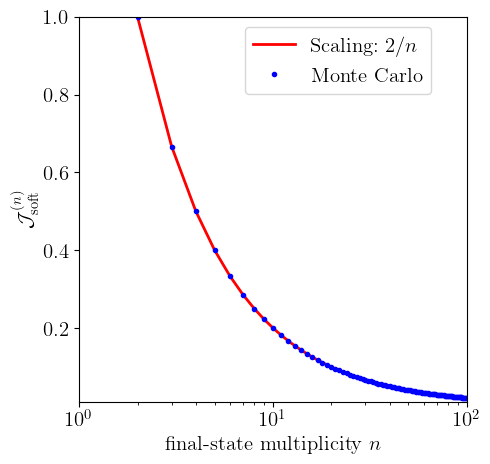

In [29]:
formula = (
    r"$T_{+}=\sum_i \dfrac{p_{x,i}^{2}-p_{y,i}^{2}}{E_i-p_{z,i}},$" "\n"
    r"$T_{\times}=2\sum_i \dfrac{p_{x,i}\,p_{y,i}}{E_i-p_{z,i}},$" "\n"
    r"$Q_{\rm soft}^{\rm TT}=T_{+}^{2}+T_{\times}^{2}$"
)

fig, ax = plt.subplots(figsize=(5,5))

plt.plot(
    df_soft["n"],
    df_soft["2/n"],
    color='r',
    linewidth=2,
    linestyle="-",
    label=r"$\text{Scaling:}~2/n$",
)

plt.plot(
    df_soft["n"],
    df_soft["ratio to n=2"],
    # yerr=df_soft["ratio error"],
    color='b',
    marker="o",
    markersize=3,
    linestyle="none",
    label=r"Monte Carlo",
)

# plt.errorbar(
#     df_naive["n"],
#     df_naive["ratio to n=2"],
#     yerr=df_naive["ratio error"],
#     marker="s",
#      color='g',
#     linestyle="none",
#     label=r"$\text{without} ~ 1/(p_i \cdot \omega)$",
# )



plt.xlabel(r"final-state multiplicity $n$")
# plt.ylabel(
#     r"$\mathcal{J}^{(n)}_{\text{soft}} =\langle Q_{\rm soft}^{\rm TT}\rangle_n/"
#     r"\langle Q_{\rm soft}^{\rm TT}\rangle_2$"
# )

plt.ylabel(
    r"$\mathcal{J}^{(n)}_{\text{soft}}$"
)

# plt.text(
#     0.45, 0.55, formula,
#     transform=plt.gca().transAxes,
#     fontsize=13,
#     verticalalignment="top",
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
# )

ax.set_xlim(1, 100)
ax.set_ylim(1e-2,1e0)
ax.set_xscale('log')
# ax.set_yscale('log')

# ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.6)
ax.legend(loc='upper left', bbox_to_anchor=(0.4, 1), prop={'size': 15})
plt.savefig("./Jn.pdf", bbox_inches="tight")

plt.show()


## Interpretation

The soft-eikonal TT observable is the relevant classical analog of the Weinberg soft residue. It includes the denominators $p_i\cdot\omega$, so the energy weighting is effectively linear rather than quadratic.

If the soft-eikonal Monte Carlo follows $2/n$, this supports the physical interpretation:
$$
\mathcal J_{\rm soft}^{(n)}\sim \frac{2}{n}
$$
because increasing multiplicity distributes the hard energy more isotropically, reducing the transverse-traceless stress seen by a soft graviton.

The naive TT observable is still useful as a warning: without the soft denominators, the suppression is much stronger and does not test the same object as the soft-graviton residue.
